## **Práctica 5**
Paula Andrea Cano | Pamela Huacca Arce

**3.2 Representación de señales**

In [4]:
import numpy as np
import matplotlib.pyplot as plt

Muestra 0: x = 0.0000, x1 = 0.0000 - Coinciden
Muestra 1: x = 1.2434, x1 = 1.2434 - Coinciden
Muestra 2: x = 2.4088, x1 = 2.4088 - Coinciden
Muestra 3: x = 3.4227, x1 = 3.4227 - Coinciden
Muestra 4: x = 4.2216, x1 = 4.2216 - Coinciden


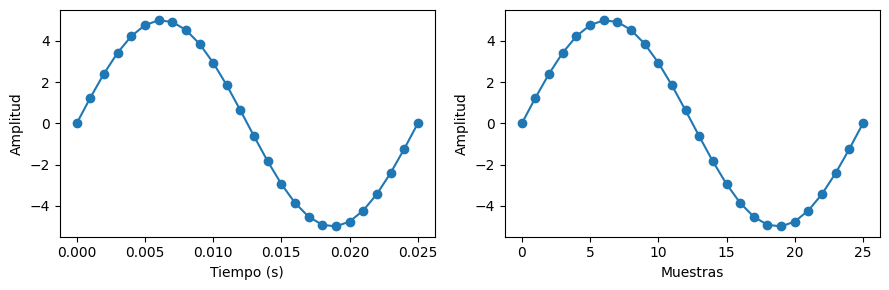

In [ ]:
# Parámetros de la señal 
Fo = 40 # Frecuencia fundamental de la señal
Tp = 1/Fo # Periodo de la señal
Fs = 1000 # Frecuencia de muestreo
T = 1/Fs # Periodo de muestreo
t = np.arange(0, Tp+T, T) # Tiempo para un ciclo de la señal con duración de Tp más una muestra T
A = 5

# Gráfica de la señal en función del tiempo
x = A*np.sin(2*np.pi*Fo*t)
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(t, x, marker='o')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')


# Gráfica de la señal en función del número de muestras
fo = Fo/Fs
n = np.arange(0, len(t))
x1 = A*np.sin(2*np.pi*fo*n)
plt.subplot(1, 2, 2)
plt.plot(n, x1, marker='o')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')


plt.tight_layout()

# se comprueba que los valores de las primeras cinco muestras son los mismos
for i in range(5):
    assert np.isclose(x[i], x1[i]), f"Las muestras no coinciden en la posición {i}: {x[i]} != {x1[i]}"
    print(f"Muestra {i}: x = {x[i]:.4f}, x1 = {x1[i]:.4f} - Coinciden")

**3.3 Energía y potencia en el dominio del tiempo**

In [ ]:
# Para 10 ciclos de la señal en función del tiempo
t10 = np.arange(0,10*Tp+T,T)
x10 = A*np.sin(2*np.pi*Fo*t10)
energia10 = sum(x10**2)
potencia10 = energia10/(len(t10)-1)
rms10 = np.sqrt(potencia10)

#Para x(n) 
energia = sum(x**2)
potencia = energia/(len(t)-1)
rms = np.sqrt(potencia)

# ¿La potencia es la misma que en x(n)?, ¿Por qué?
print('Para 10 ciclos de la señal en función del tiempo:')
print(f"Potencia en función del tiempo: {potencia10}")
print(f"RMS en función del tiempo: {rms10}")
print('\nPara x(n):')
print(f"Potencia en función de las muestras: {potencia}")
print(f"RMS en función de las muestras: {rms}")


Para 10 ciclos de la señal en función del tiempo:
Potencia en función del tiempo: 12.500000000000005
RMS en función del tiempo: 3.535533905932738

Para x(n):
Potencia en función de las muestras: 12.500000000000002
RMS en función de las muestras: 3.5355339059327378


En el caso de la evalucaión de la potencia de la señal para 10 ciclos, se obtiene el mismo resultado que para un ciclo, ya que la potencia es una medida de la energía promedio de la señal por unidad de tiempo. Dado que la señal es periódica, la energía total en 10 ciclos será 10 veces la energía en un ciclo, pero como también se está considerando un tiempo 10 veces mayor, la potencia promedio se mantiene constante. Por lo tanto, la potencia calculada para 10 ciclos es la misma que la calculada para un solo ciclo.

**4.1 Señal con tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz.  Frecuencia de muestreo mínima necesaria para representar la señal, y frecuencia de muestreo necesaria para representar la señal apropiadamente** 


Recordando el Teorema de Muestreo de Nyquist, para digitalizar una señal sin perder información, la frecuencia de muestreo debe ser al menos el  doble de la frecuencia maxima de la señal. Las frecuencias que tenemos son 40, 80 y 160 Hz, por lo que la frecuencia máxima es 160 Hz.  Por lo tanto, la frecuencia de muestreo  minima necesaria es 320

In [23]:
f1 = 40  # Hz
f2 = 80  # Hz
f3 = 160 # Hz

# Frecuencia de muestreo será el doble de la frecuencia máxima presente en la señal para cumplir el teorema de Nyquist
f_max = 160
fs = 2 * f_max   #  Frecuencia de muestreo mínima necesaria para evitar aliasing
T = 1 / fs # Periodo de muestreo
print(f"Frecuencia de muestreo minima necesaria: {fs} Hz")

"""Aumentando la frecuencia de muestreo a 1000 Hz pode obtener una mejor representación de la señal,
ya que al aumentarla aumenta también la distacia entre la parte real y el alias permitieno una mejor
operabilidad en los datos y una mejor representación de la señal"""
fs2 = 1000
T2 = 1 / fs2
print(f"\nFrecuencia de muestreo utilizada para una representación apropiada: {fs2} Hz")



Frecuencia de muestreo minima necesaria: 320 Hz

Frecuencia de muestreo utilizada para una representación apropiada: 1000 Hz


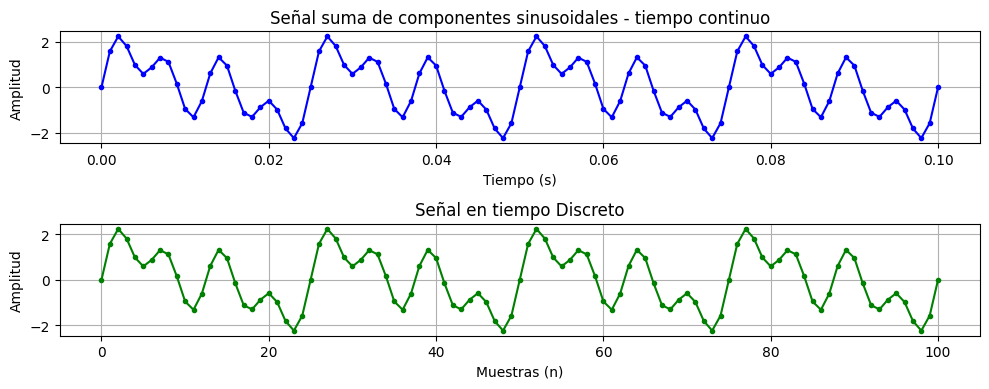

In [35]:
# Gráfica de un segmento de la señal
t = np.arange(0, 0.1+T2, T2)

# Creación de la señal - (NO ESTOY SEGRUA DE LA AMPLITUD coloqué vaores aleatorios)
#x = np.sin(2 * np.pi * f1 * t) + 0.5*np.sin(2 * np.pi * f2 * t) + 0.25*np.sin(2 * np.pi * f3 * t)
x = np.sin(2 * np.pi * f1 * t) + np.sin(2 * np.pi * f2 * t) + np.sin(2 * np.pi * f3 * t)

plt.figure(figsize=(10, 4))
plt.subplot(2, 1, 1)
plt.plot(t, x, marker='.', color='b')
plt.title('Señal suma de componentes sinusoidales - tiempo continuo')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)

# En tiempo discreto
fo1, fo2, fo3 = f1/fs2, f2/fs2, f3/fs2
n = np.arange(0, len(t)) 

#x_discreta = np.sin(2*np.pi*fo1*n) + 0.5*np.sin(2*np.pi*fo2*n) + 0.25*np.sin(2*np.pi*fo3*n)
x_discreta = np.sin(2*np.pi*fo1*n) + np.sin(2*np.pi*fo2*n) + np.sin(2*np.pi*fo3*n)

plt.subplot(2, 1, 2)
plt.plot(n, x_discreta, marker='.', color='g')
plt.title('Señal en tiempo Discreto')
plt.xlabel('Muestras (n)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.tight_layout()



**4.2 Transformada de Fourier de la señal y espectro de frecuencia de la señal**

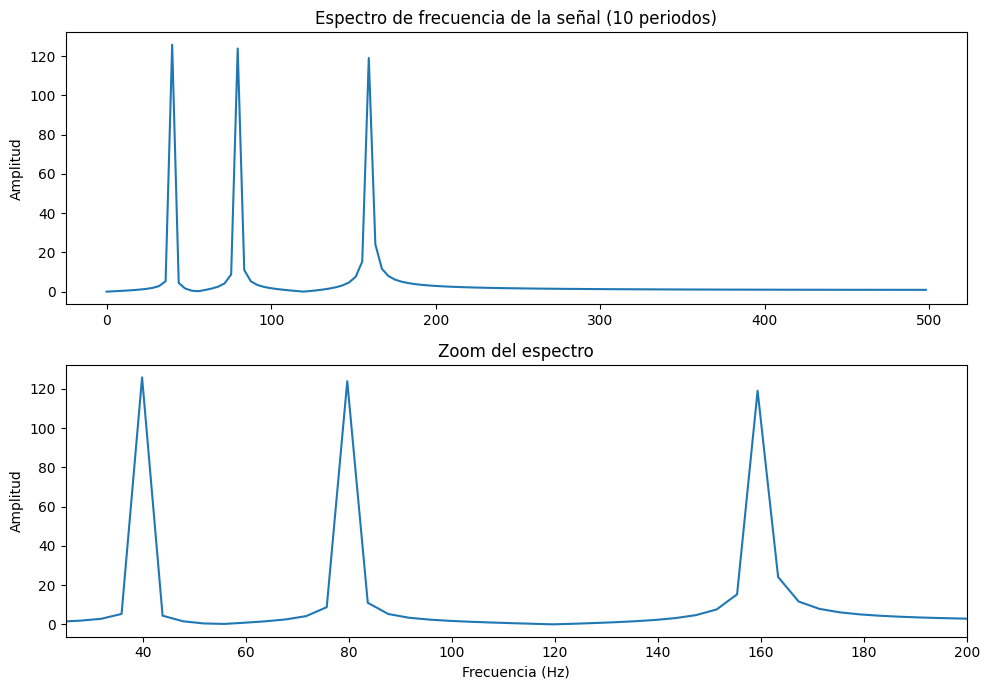

In [51]:
fo = 40       # Frecuencia fundamental se determina con MCD de las tres frecuencias
Tp = 1/fo     # Periodo fundamental

# Definimos los 10 periodos de la señal 
t10 = np.arange(0, 10*Tp+T2, T2) 
x10 = np.sin(2*np.pi*f1*t10) + np.sin(2*np.pi*f2*t10) + np.sin(2*np.pi*f3*t10)

#  Análisis de Fourier en tiempo discreto 
X10 = np.fft.fft(x10) # Transformada Discreta de Fourier
N = len(X10)

# Graficar solo la mitad de los puntos (Frecuencia Nyquist)
Nmitad = int(np.ceil(N/2))
Fmitad = np.arange(0, Nmitad) * fs2 / N
X10mitad = X10[0:Nmitad]

plt.figure(figsize=(10, 7))
plt.subplot(2, 1, 1)
plt.plot(Fmitad, abs(X10mitad))
plt.title('Espectro de frecuencia de la señal (10 periodos)')
plt.ylabel('Amplitud')

# Hacemos un zoom en el eje X para poder observar bien las componentes (hasta 200 Hz)
plt.subplot(2, 1, 2)
plt.plot(Fmitad, abs(X10mitad))
plt.ylabel('Amplitud')
plt.xlabel('Frecuencia (Hz)')
plt.title('Zoom del espectro')
plt.xlim(25, 200)

plt.tight_layout()


Al realizar un zoom en el espectro de frecuencia entre 25 y 200 Hz, se observan claramente tres picos principales. Estos picos se encuentran ubicados exactamente en 40 Hz, 80 Hz y 160 Hz, lo cual comprueba y corresponde  a las frecuencias de las tres componentes sinusoidales con las que se construyó originalmente la señal en el dominio del tiempo

**4.3 Transformada inversa de Fourier**

La transformada inversa de Fourier es el proceso de convertir una representación de una señal en el dominio de la frecuencia de nuevo al dominio del tiempo [1]. Sirve para devolvernos, es decir, si tomamos el espectro de frecuencias que calculamos en el punto anteiror y le aplicamos la inversa, debemos obtener exactamente la misma señal en el tiempo que teníamos al principio.

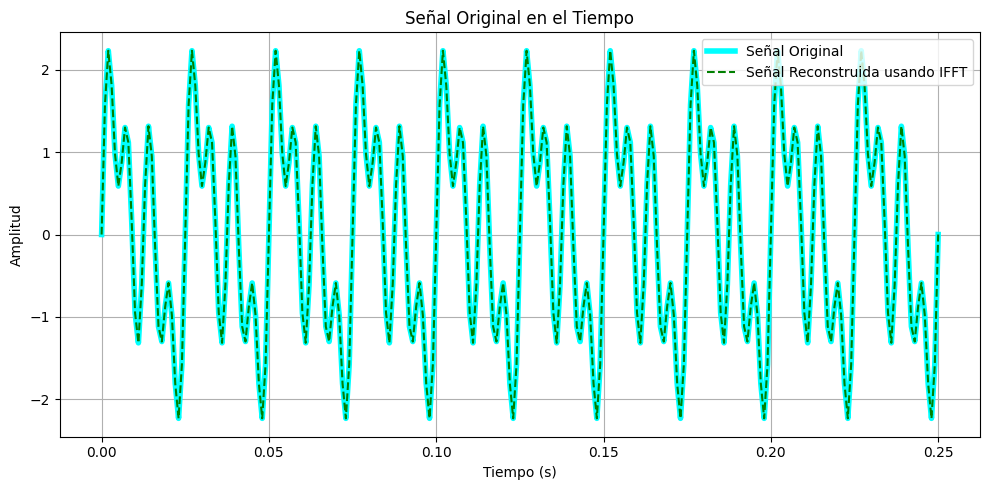

In [ ]:
# Aplicamos la función ifft al espectro X10 calculado en el Punto anterior para obtener la señal reconstruida en el tiempo
x_reconstruida = np.fft.ifft(X10)

# Como los resultados de la ifft pueden tener una pequeñísima parte imaginaria 
# por errores de redondeo computacional, tomamos solo la parte real
x_reconstruida_real = np.real(x_reconstruida)


plt.figure(figsize=(10, 5))

# señal original 
plt.plot(t10, x10, color='aqua', label='Señal Original', linewidth=4)
plt.title('Señal Original en el Tiempo')
plt.ylabel('Amplitud')
plt.grid(True)

# señal reconstruida
plt.plot(t10, x_reconstruida_real, color='green', linestyle='--', label='Señal Reconstruida usando IFFT')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**4.4**

Sí, se puede afirmar que las líneas de código aplican un filtro. Al arreglo de ceros creado $(F2 = np.zeros(...))$ se le introduce una parte de la señal original acotada en un invtervalo específico$(F2[9:13] = F1[9:13])$, por lo que todo lo que esté por fuera del intervalo se convierte en cero, guardando solo un segmento de la señal original, luego a este segmento se le aplica la Transformada Inversa.

Finalmente, al aplicar la transformada inversa (ifft), la onda que recuperamos en el tiempo solo contiene esa frecuencia que dejamos pasar. Como se descartó el resto de la señal y conservamos solo una parte, estamos aplicando un filtro. Y para determinar qué rango copiar, sabemos que al dividir la frecuencia de muestreo $1000 Hz$ entre el número de muestras $250$, cada posición del arreglo equivale a saltos de $4 Hz$. Por lo tanto, para extraer la componente de $40 Hz$ nos ubicamos alrededor de la posición $10$ (rango $[9:13]$), para la de $80 Hz$ en la posición $20$ (rango $[19:23]$), y para la de $160 Hz$ en la posición $40$ (rango $[39:43]$), de esa manera podemos reconstruir cada onda por separado.

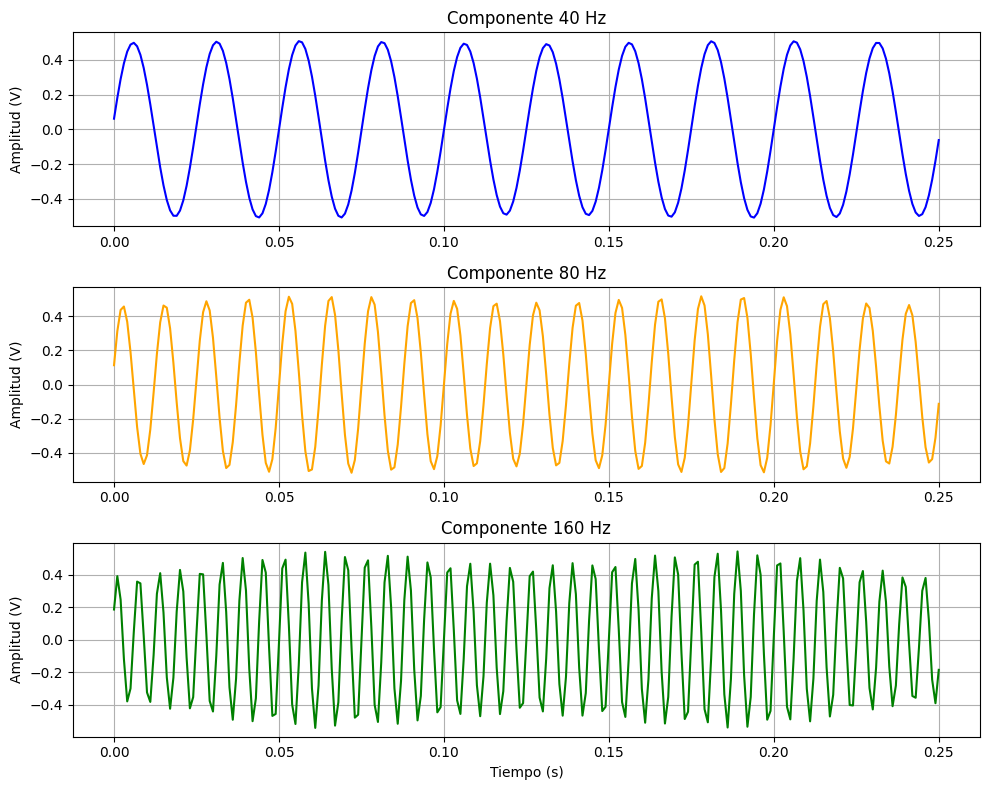

In [60]:
# Usamos la señal x10
F1 = np.fft.fft(x10) 

#  componente de 40 Hz 
F2_40 = np.zeros((len(F1)), dtype=complex)
F2_40[9:13] = F1[9:13]
xr_40 = np.fft.ifft(F2_40)

# componente de 80 Hz
F2_80 = np.zeros((len(F1)), dtype=complex)
F2_80[19:23] = F1[19:23]
xr_80 = np.fft.ifft(F2_80)

# Extraer la componente de 160 Hz 
F2_160 = np.zeros((len(F1)), dtype=complex)
F2_160[39:43] = F1[39:43]
xr_160 = np.fft.ifft(F2_160)

#  Grafica
fig, axs = plt.subplots(3, 1, figsize=(10, 8))

axs[0].plot(t10, np.real(xr_40), color='blue')
axs[0].set(ylabel='Amplitud (V)', title='Componente 40 Hz')
axs[0].grid(True)

axs[1].plot(t10, np.real(xr_80), color='orange')
axs[1].set(ylabel='Amplitud (V)', title='Componente 80 Hz')
axs[1].grid(True)

axs[2].plot(t10, np.real(xr_160), color='green')
axs[2].set(xlabel='Tiempo (s)', ylabel='Amplitud (V)', title='Componente 160 Hz')
axs[2].grid(True)

plt.tight_layout()

**4.5 Espectro y filtro en una señal ECG**

In [ ]:
import scipy.io as sio
#import mne
from scipy.signal import welch 

data = sio.loadmat('senecg.mat')
print(data.keys())
print(data['ECG'].shape)

dict_keys(['__header__', '__version__', '__globals__', 'ECG'])
(1250, 1)


Text(0.5, 1.0, 'Señal ECG')

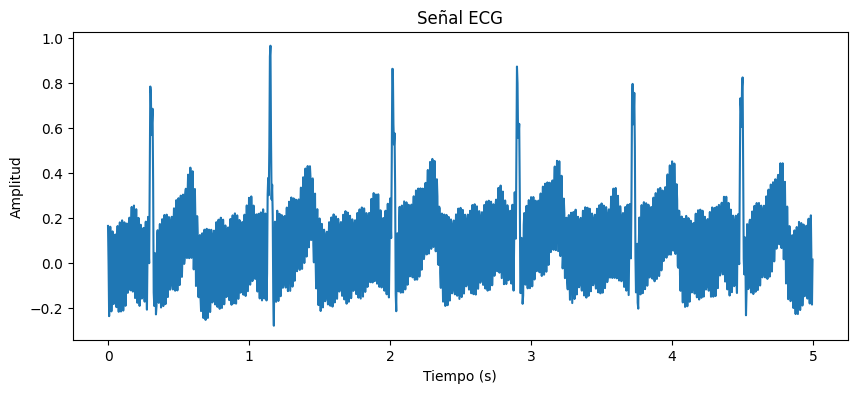

In [102]:
ecg = data['ECG'].flatten() 
Fs = 250
Ts = 1/Fs
t = np.arange(len(ecg)) / Fs

plt.figure(figsize=(10, 4))
plt.plot(t, ecg)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Señal ECG')

El ancho de la ventana (resolución) del periodograma de Welch se determina por el número de muestras por segmento (nperseg) y proporciona una resolución de la ventana. Se calcula como $fs/nperseg$. Aplicando a este conjunto de datos, la resulución de la ventana sería de aproximadamente $0.49 Hz$, creando ventanas de aproximada mente dos segundos, que es un ancho de ventana de que permité captar por lo menos uno o dos ciclos cardico en ese tiempo lo que ermite evaluar las características del ECG. El solapamiento del 50% permite operar sin perder datos que se atenuen entre ventanas.

Text(0.5, 1.0, 'Periodograma de Welch - ECG')

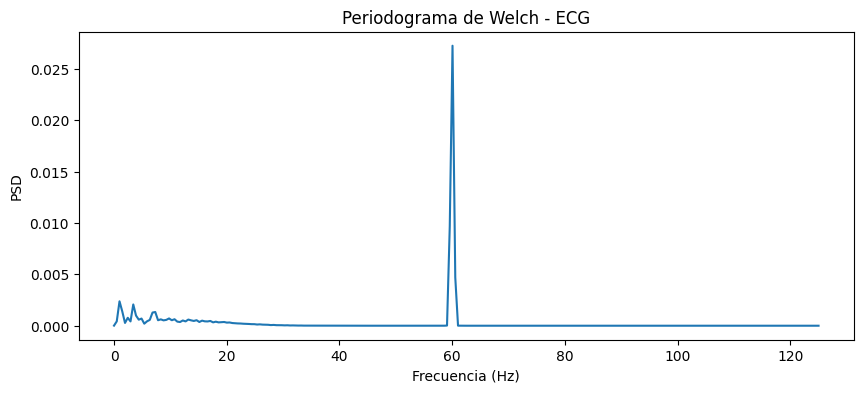

In [ ]:
# Periodograma de Welch de la señal ECG

nperseg = 512
noverlap = nperseg // 2

f, Pxx = welch(ecg, fs=250, window='hann', nperseg=nperseg, noverlap=noverlap)

plt.figure(figsize=(10, 4))
plt.plot(f, Pxx)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.title('Periodograma de Welch - ECG')
#plt.xlim([0, 125])  # hasta Nyquist

(0.0, 0.003)

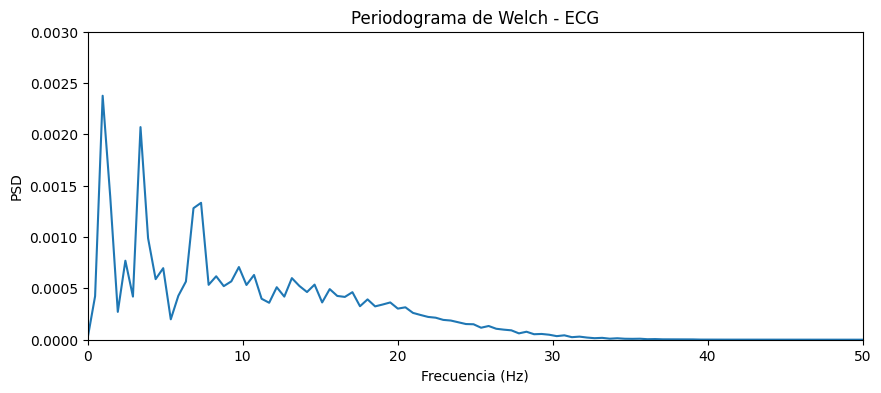

In [106]:
plt.figure(figsize=(10, 4))
plt.plot(f, Pxx)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.title('Periodograma de Welch - ECG')
plt.xlim([0, 50])  # Zoom para ver mejor las componentes de interés
plt.ylim((0, 0.003))

Conservaremos la señal en un rago de frecuencias de 0 a 40 Hz, debido a que no se observa actividad en frecuencias superiores. Filtrando a este rango eliminamos además el ruido de la red eléctrica de 60 Hz.

In [ ]:
N = len(ecg)
F_ecg = np.fft.fft(ecg)
F_filtrada = np.zeros(N, dtype=complex)

# Frecuencias a conservar, (según literatura sobre el ECG y según lo que se observa en el periodograma)
f_min = 0.5
f_max = 40.0

k_min = int(np.round(f_min * N / Fs))
k_max = int(np.round(f_max * N / Fs))


F_filtrada[k_min:k_max+1] = F_ecg[k_min:k_max+1]
F_filtrada[N-k_max:N-k_min+1] = F_ecg[N-k_max:N-k_min+1]  # parte simétrica

ecg_filtrado = np.real(np.fft.ifft(F_filtrada))

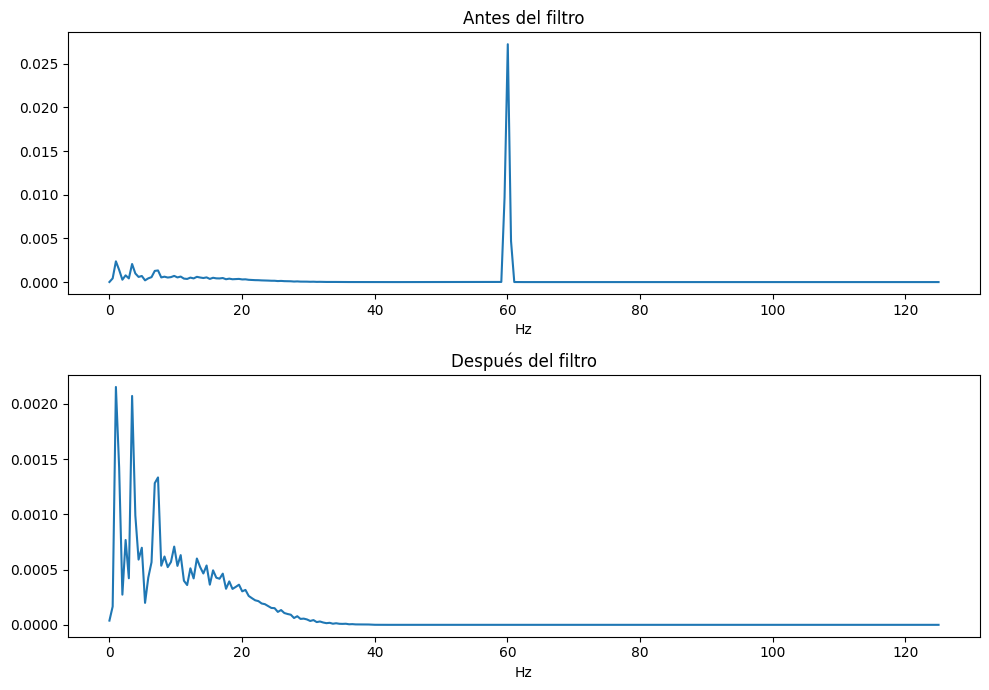

In [99]:
f2, Pxx2 = welch(ecg_filtrado, Fs, window='hann', nperseg=nperseg, noverlap=noverlap)

fig, axs = plt.subplots(2, 1, figsize=(10, 7))
axs[0].plot(f, Pxx); axs[0].set_title('Antes del filtro'); axs[0].set_xlabel('Hz')
axs[1].plot(f2, Pxx2); axs[1].set_title('Después del filtro'); axs[1].set_xlabel('Hz')
plt.tight_layout(); plt.show()

Se observa que el filtro elimina con el ruido de la señal y permitió convservar solo las frecuencias de interés.

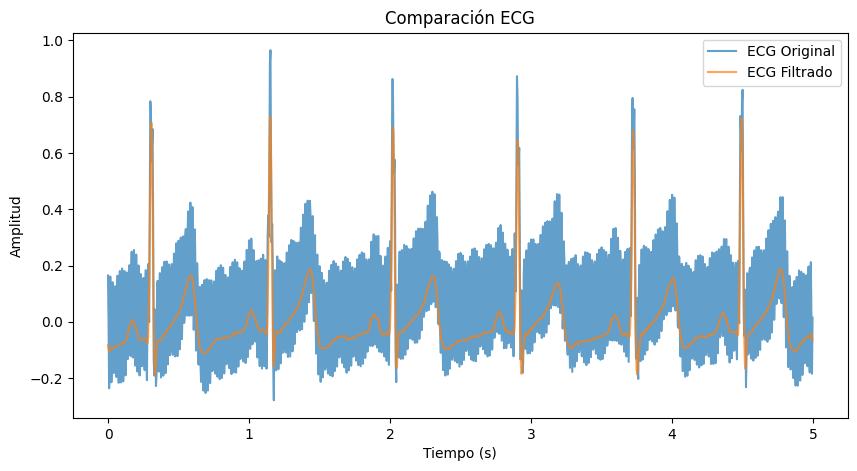

In [142]:
# LLevamos nuevamente a dominio del tiempo para comparar
t = np.arange(len(ecg)) / Fs
plt.figure(figsize=(10, 5))
plt.plot(t, ecg, label='ECG Original', alpha=0.7)
plt.plot(t, ecg_filtrado, label='ECG Filtrado', alpha=0.7)
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.title('Comparación ECG')
plt.legend()


**4.6 análisis de sujeto control vs sujeto con Parkinson**

Del proyecto 1 el canal Fp1 alcanzó rangos de significacia en la tareas de ambas manos. Sin embargo, los datos adjuntos no tiene información sobre los canales usados, por tanto se seleccionan dos canales al azar.

In [113]:
ctr = sio.loadmat("C012_EP_reposo_CONTROL.mat")
print(ctr.keys())
print(ctr['data'].shape)

dict_keys(['__header__', '__version__', '__globals__', 'data'])
(8, 2000, 172)


In [ ]:
par = sio.loadmat("P004_EP_reposo_PARKISON.mat")
print(par.keys())
print(par['data'].shape) 

dict_keys(['__header__', '__version__', '__globals__', 'data'])
(8, 2000, 138)


En los datos no hay información sobre la frecuencia de muestreo de estos. La asumiremos como 250 Hz, que es común en registros de EEG. Adicionalmente se asume que las filas corresponde a los canales (8) y las columnas a las muestras (2000). Podríamos pensar que el tercer dato de la matriz es el número de épocas analizadas, pero no tenemos certeza de esto. 

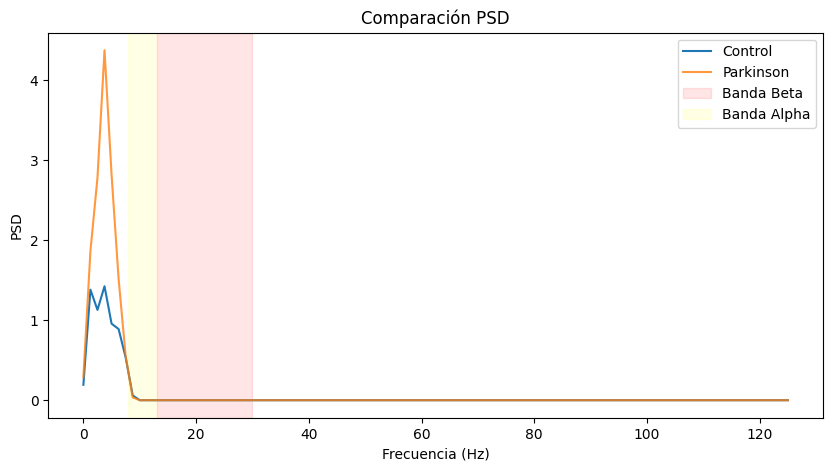

In [ ]:
Fs = 250 

"""Seleccionamos un canal y 'época' al azar"""
canal_ctr = ctr['data'][5, :, 0]
canal_par = par['data'][5, :, 0]
nperseg_eeg = 256
noverlap_eeg = nperseg_eeg // 2

f_s, Pxx_c = welch(canal_ctr,Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)
f_p, Pxx_p = welch(canal_par, Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)

plt.figure(figsize=(10,5))
plt.plot(f_s, Pxx_c, label='Control')
plt.plot(f_p, Pxx_p, label='Parkinson', alpha=0.8)
plt.axvspan(13, 30, alpha=0.1, color='red', label='Banda Beta')
plt.axvspan(8, 13, alpha=0.1, color='yellow', label='Banda Alpha')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.title(f'Comparación PSD')
plt.legend()
#plt.xlim([0, 60])

c:\Users\paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 172, using nperseg = 172
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,
c:\Users\paula\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\signal\_spectral_py.py:790: UserWarning: nperseg = 256 is greater than input length  = 138, using nperseg = 138
  freqs, _, Pxy = _spectral_helper(x, y, fs, window, nperseg, noverlap,


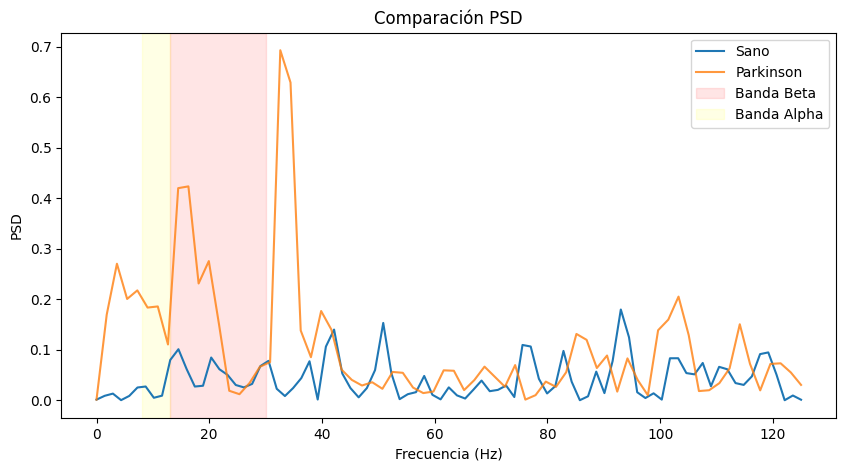

In [ ]:
canal_ctr = ctr['data'][0, 0, :]  
canal_par = par['data'][0, 0, :]  
nperseg_eeg = 256
noverlap_eeg = nperseg_eeg // 2

f_s, Pxx_s = welch(canal_ctr,Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)
f_p, Pxx_p = welch(canal_par, Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)

plt.figure(figsize=(10,5))
plt.plot(f_s, Pxx_s, label='Sano')
plt.plot(f_p, Pxx_p, label='Parkinson', alpha=0.8)
plt.axvspan(13, 30, alpha=0.1, color='red', label='Banda Beta')
plt.axvspan(8, 13, alpha=0.1, color='yellow', label='Banda Alpha')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.title(f'Comparación PSD')
plt.legend()

Graficamos el PSD en dos direcciones de los datos para verificar que se estuviera tomando bien la dirección de las muestras.

Graficamos nuevamente el PSD en un rango de fecuencia menor para realizar un análisis más preciso.

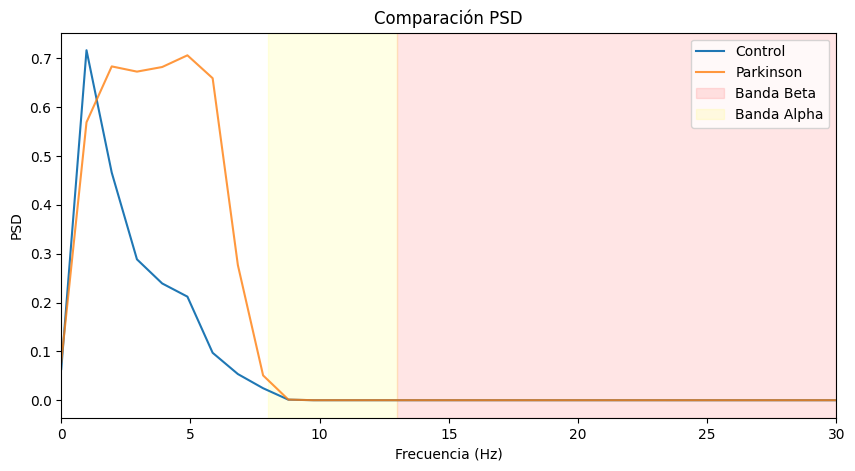

In [147]:
Fs = 250 

"""Seleccionamos un canal y 'época' al azar"""
canal_ctr = ctr['data'][1, :, 0]
canal_par = par['data'][1, :, 0]
nperseg_eeg = 256   # ajusta según Fs_eeg; busca resolución ~0.5-1 Hz
noverlap_eeg = nperseg_eeg // 2

f_s, Pxx_c = welch(canal_ctr,Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)
f_p, Pxx_p = welch(canal_par, Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)

plt.figure(figsize=(10,5))
plt.plot(f_s, Pxx_c, label='Control')
plt.plot(f_p, Pxx_p, label='Parkinson', alpha=0.8)
plt.axvspan(13, 30, alpha=0.1, color='red', label='Banda Beta')
plt.axvspan(8, 13, alpha=0.1, color='yellow', label='Banda Alpha')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.title(f'Comparación PSD')
plt.xlim([0, 30])
plt.legend()

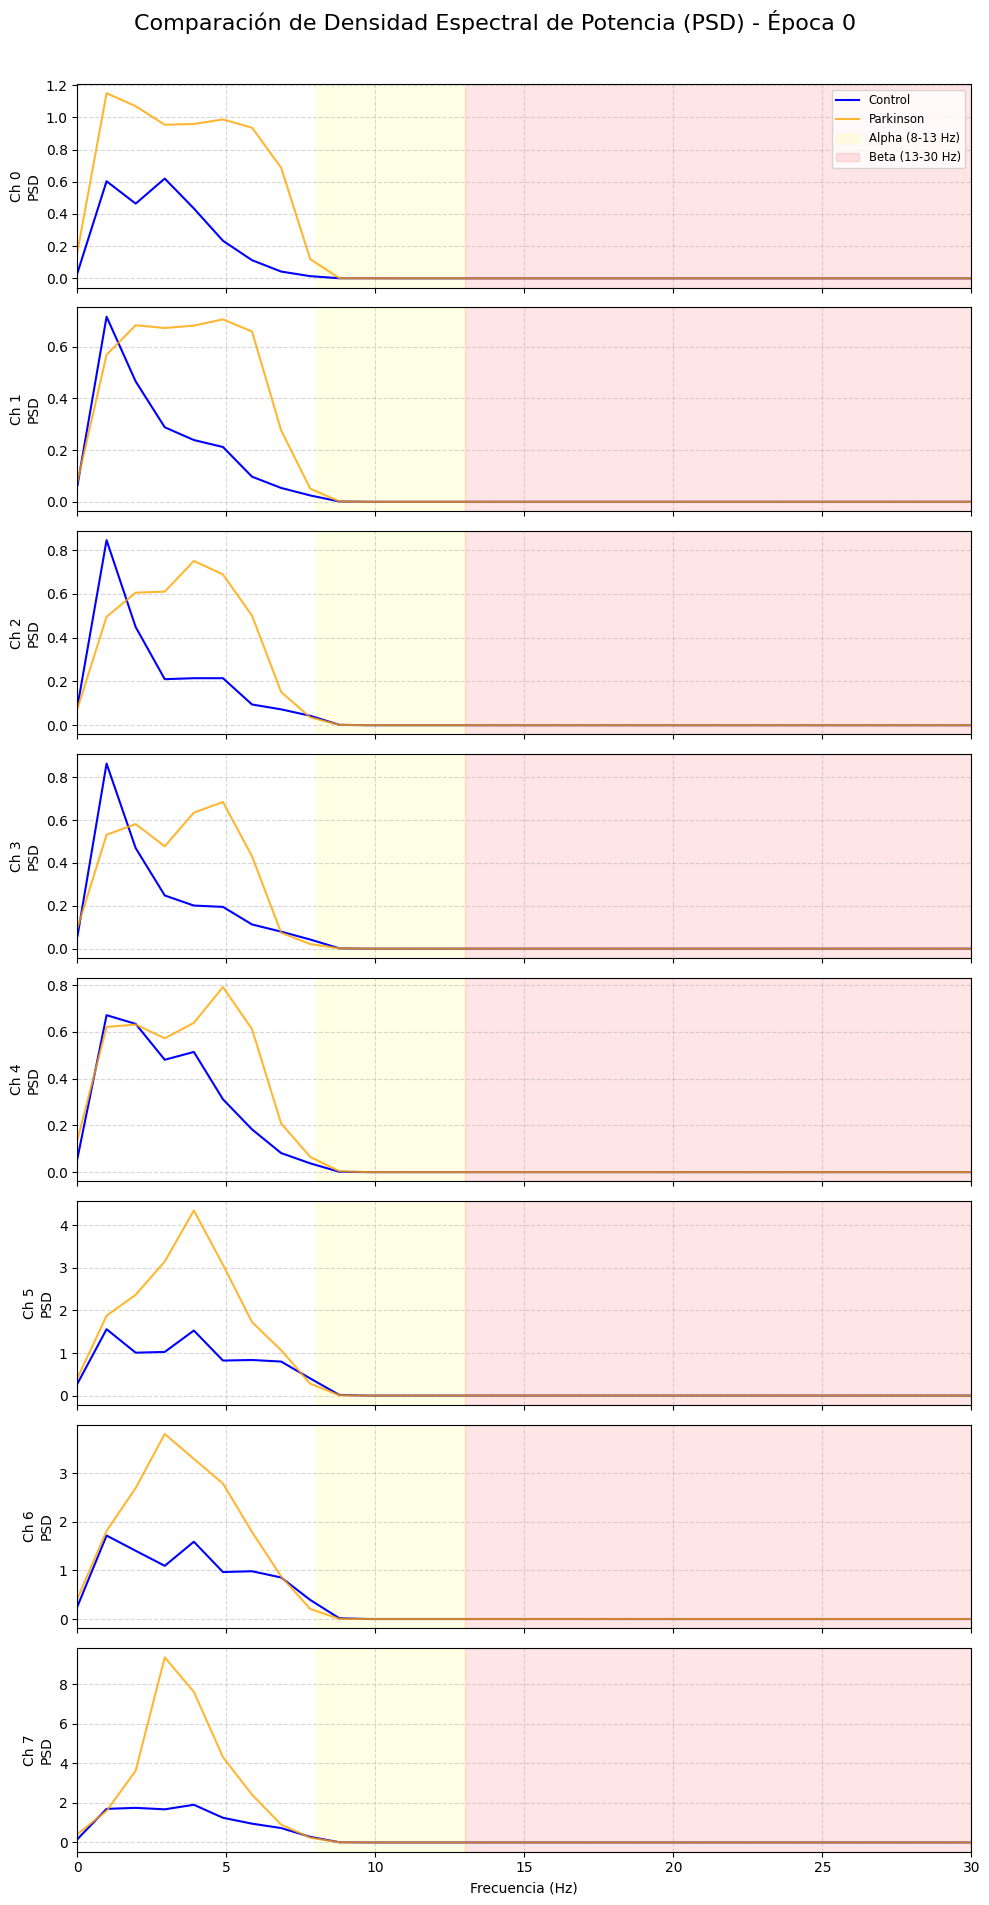

In [ ]:
n_channels = 8
indice_epoca = 0

# Creamos la figura con 8 subplots (uno por canal)
fig, axes = plt.subplots(n_channels, 1, figsize=(10, 20), sharex=True)

for i in range(n_channels):
    canal_ctr = ctr['data'][i, :, indice_epoca]
    canal_par = par['data'][i, :, indice_epoca]
    
    f_s, Pxx_c = welch(canal_ctr, Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)
    f_p, Pxx_p = welch(canal_par, Fs, window='hann', nperseg=nperseg_eeg, noverlap=noverlap_eeg)
    
    ax = axes[i]
    ax.plot(f_s, Pxx_c, label='Control', color='blue', lw=1.5)
    ax.plot(f_p, Pxx_p, label='Parkinson', color='orange', alpha=0.8, lw=1.5)
   
    ax.axvspan(8, 13, alpha=0.1, color='yellow', label='Alpha (8-13 Hz)' if i == 0 else "")
    ax.axvspan(13, 30, alpha=0.1, color='red', label='Beta (13-30 Hz)' if i == 0 else "")
    
    ax.set_ylabel(f'Ch {i}\nPSD')
    ax.set_xlim([0, 30])
    ax.grid(True, linestyle='--', alpha=0.5)
    
    if i == 0:
        ax.legend(loc='upper right', fontsize='small')

plt.xlabel('Frecuencia (Hz)')
plt.suptitle(f'Comparación de Densidad Espectral de Potencia (PSD) - Época {indice_epoca}', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])

Creemos que los datos proporcionados tiene algunas inconsistencias que impiden el correcto análisis, al ser un análisis en estado de reposo se esperaría que por lo menos los datos del sujeto control presentran un pico en la banda alfa, sin embargo, esto no se ve en ninguno de los canales, es por esto que se grafican todos los canales para verificar el comportamiento de los datos, y todas las gráficas obtenidas son inconsistentes.

**4.7 Conclusiones**

1. Se comprobó la importancia práctica del teorema de Muestreo de Nyquist al momento de digitalizar señales. Al usar una frecuencia de muestreo de 1000 Hz (mucho mayor al mínimo necesario de 320 Hz, que es el doble de nuestra frecuencia máxima de la señal total) se logró obtner una copia digital muy fiel a la señal original. De esta forma, evitamos que la onda se deformara (un error conocido como aliasing) y no perdimos información importante de la señal en el tiempo. 

2. La Transformada Rápida de Fourier (FFT) es una herramienta analítica muy importante, porque mientras que en el dominio del tiempo la suma de las tres ondas sinusoidales se visualizaba como una única señal compleja y difícil de interpretar a simple vista, pasarlo al dominio de la frecuencia permitió descomponerla e identificar con exactitud tanto la ubicación (40, 80 y 160 Hz) como la amplitud de cada una de sus componentes fundamentales.

3. El cálculo de la Transformada Inversa de Fourier (IFFT) nos permite validar que la transformación entre el dominio del tiempo y la frecuencia es un proceso matemáticamente reversible. Se logró reconstruir la señal original en el tiempo a partir de su espectro frecuencial sin ninguna pérdida de información o deformación en su estructura.

4. Se comprobó que por medio del periodograma de Welch podemos obtener información sobre el ruido que compone una señal e identificar el tipo de filtrado necesario para corregir la señal. Además se probó una técnica de filtrado de paso de banda nueva a partir de un vector de ceros y la eficiencia de la misma. 


**Referencias**

[1] “NUMPY - Inverse Fourier Transform.” https://www.tutorialspoint.com/numpy/numpy_inverse_fourier_transform.htm



